In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json

import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import glob
import random
from multiprocessing import Pool, cpu_count


sys.path.append(os.path.abspath(os.path.join('..')))

from src.random_graph import *
from src.plot import *
from src.process_data import *

Loaded graph from ../../data/graphs/yeast_g.graphml.
Loaded graph stats from ../../data/graphs/yeast_stat.json.
Loaded graph motif counts from ../../data/graphs/yeast_motifs.json.


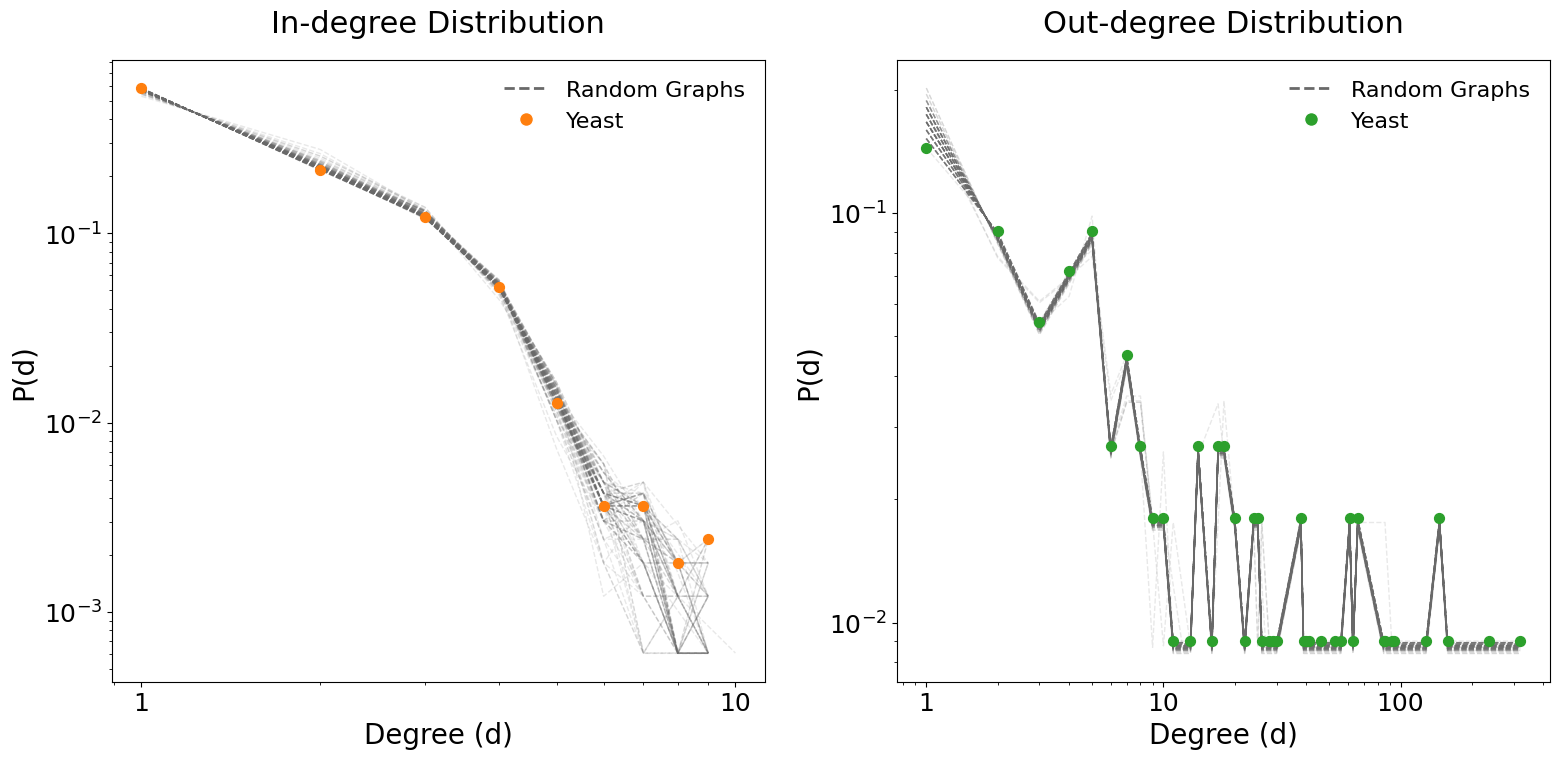

Loaded graph from ../../data/graphs/hESC_g.graphml.
Loaded graph stats from ../../data/graphs/hESC_stat.json.
Loaded graph motif counts from ../../data/graphs/hESC_motifs.json.


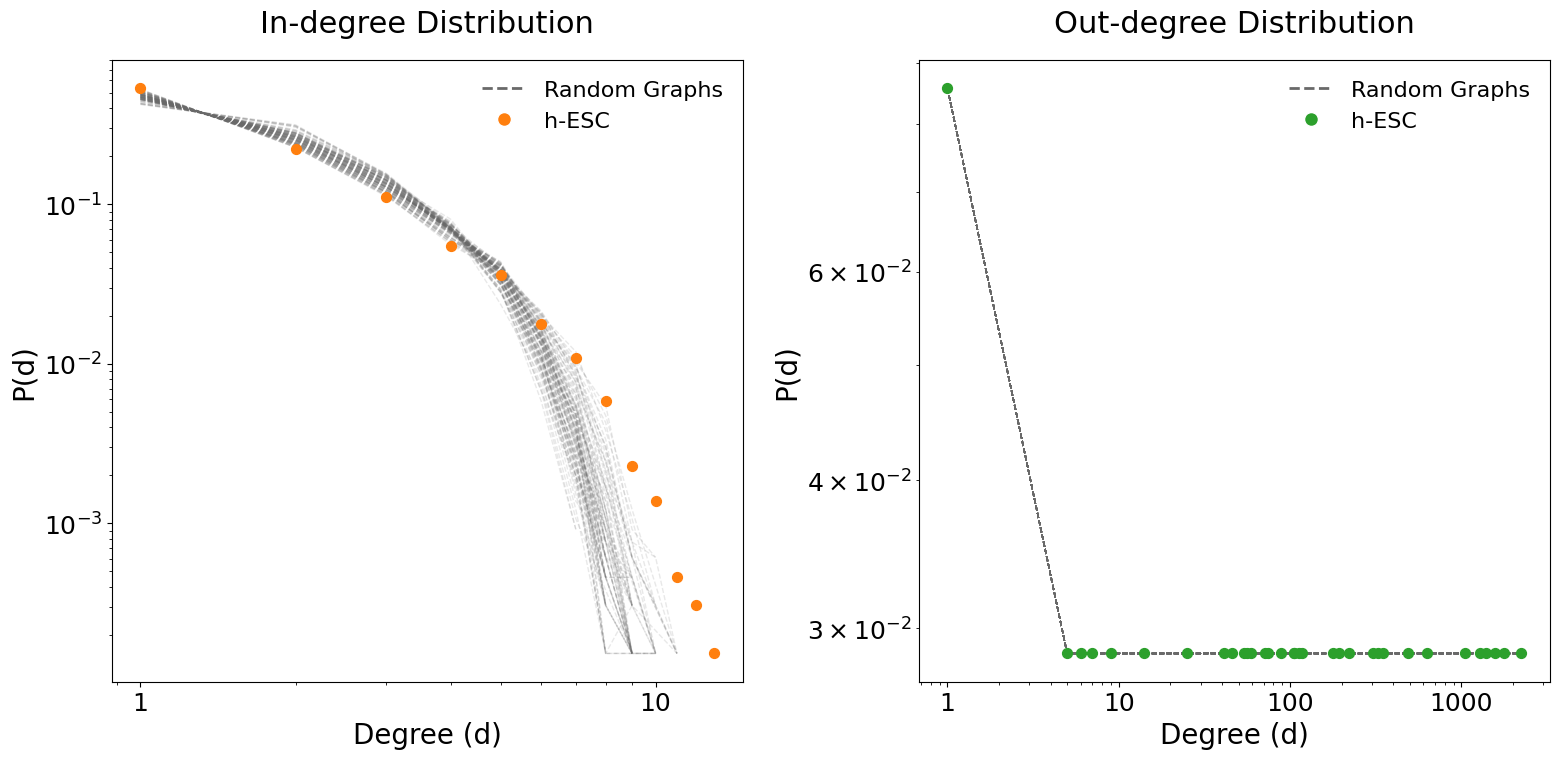

Loaded graph from ../../data/graphs/mESC_g.graphml.
Loaded graph stats from ../../data/graphs/mESC_stat.json.
Loaded graph motif counts from ../../data/graphs/mESC_motifs.json.


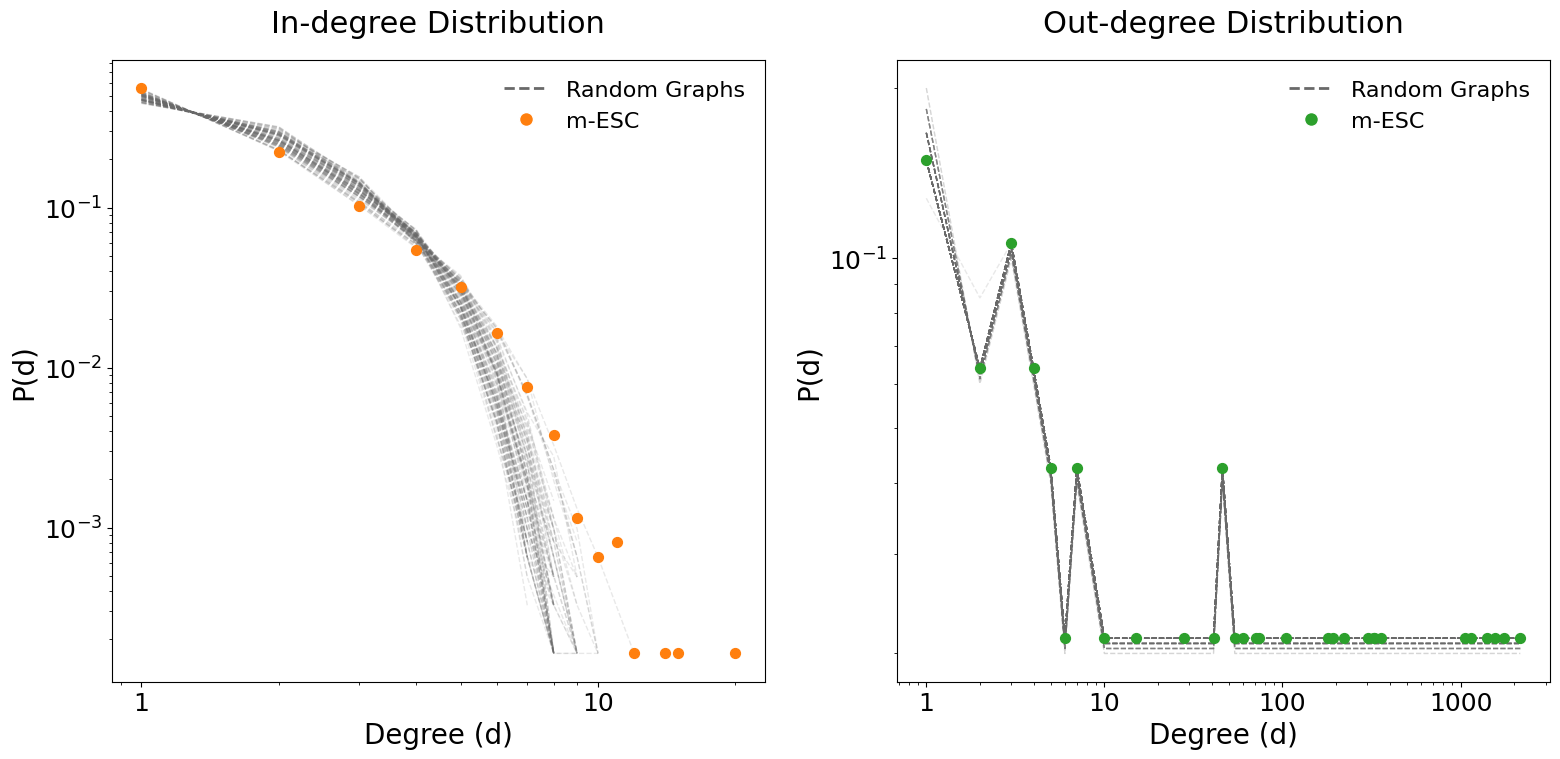

Loaded graph from ../../data/graphs/ecoli_gnw_g.graphml.
Loaded graph stats from ../../data/graphs/ecoli_gnw_stat.json.
Loaded graph motif counts from ../../data/graphs/ecoli_gnw_motifs.json.


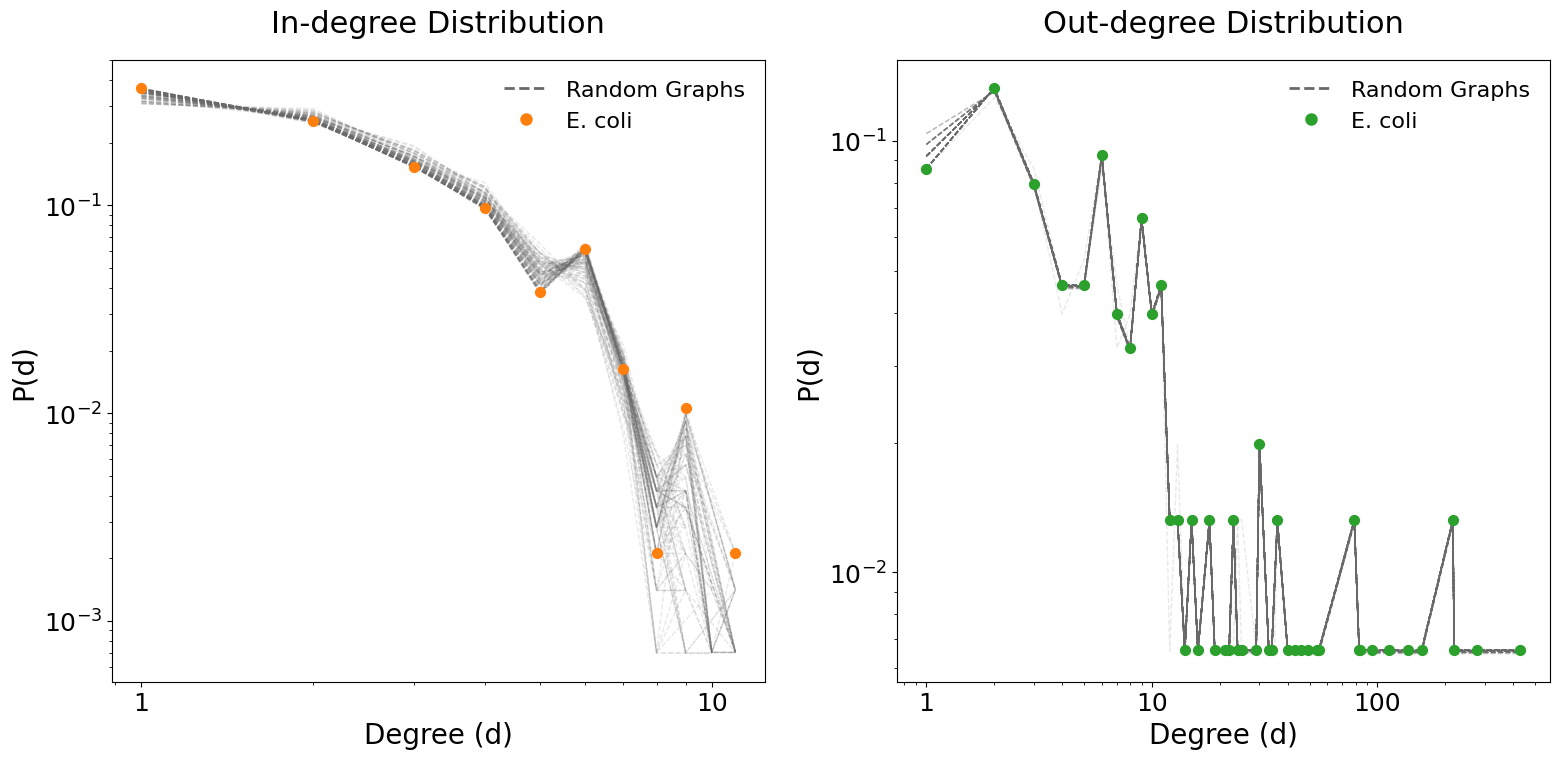

Loaded graph from ../../data/graphs/human_trrust_g.graphml.
Loaded graph stats from ../../data/graphs/human_trrust_stat.json.
Loaded graph motif counts from ../../data/graphs/human_trrust_motifs.json.


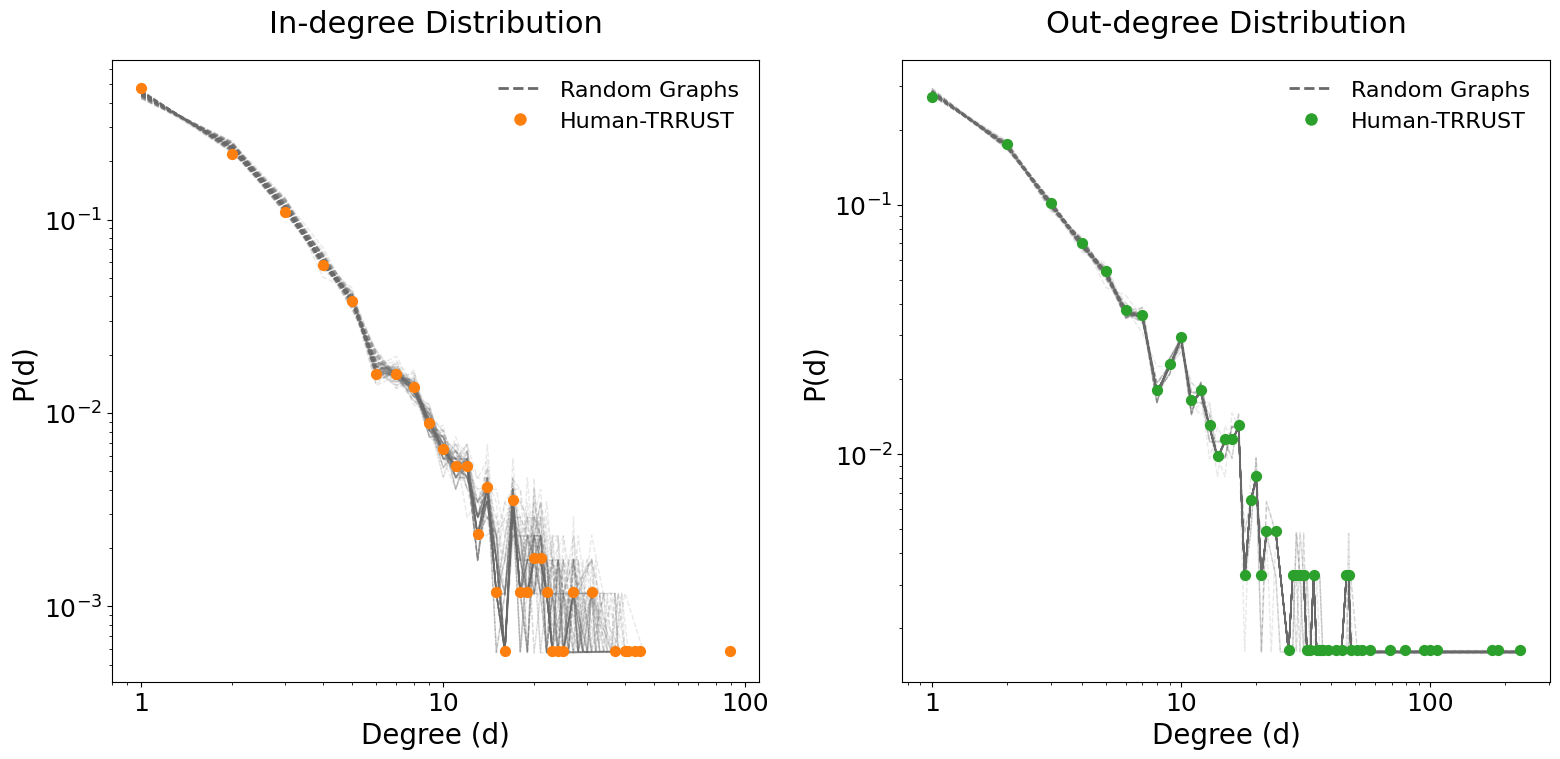

Loaded graph from ../../data/graphs/ecoli_wolf_g.graphml.
Loaded graph stats from ../../data/graphs/ecoli_wolf_stat.json.
Loaded graph motif counts from ../../data/graphs/ecoli_wolf_motifs.json.


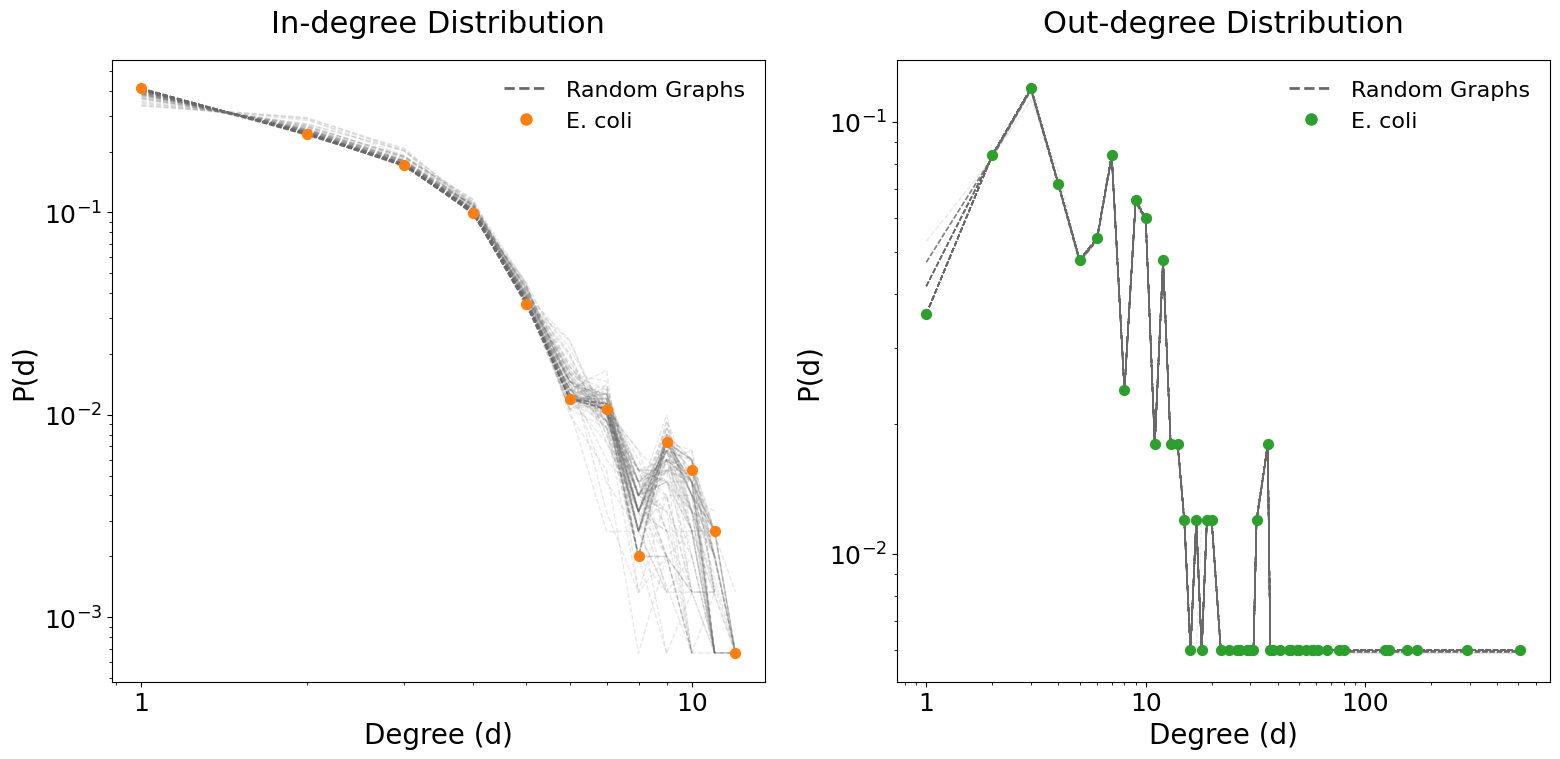

Loaded graph from ../../data/graphs/mDC_g.graphml.
Loaded graph stats from ../../data/graphs/mDC_stat.json.
Loaded graph motif counts from ../../data/graphs/mDC_motifs.json.


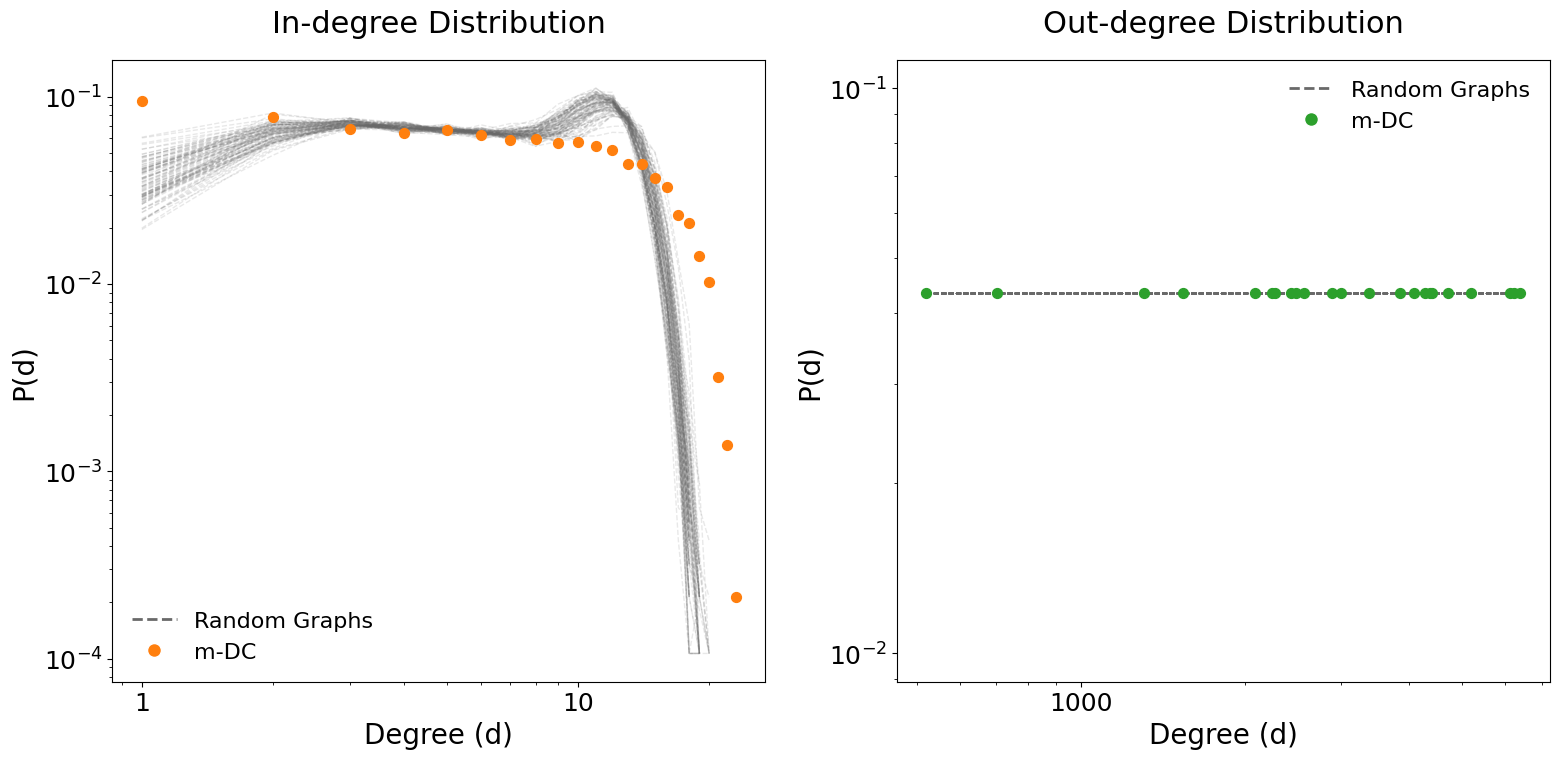

In [4]:
plt.rcParams.update({
    'font.size': 20,           
    'axes.titlesize': 22,      
    'axes.labelsize': 20,      
    'xtick.labelsize': 18,     
    'ytick.labelsize': 18,     
    'legend.fontsize': 16,     
})

def _extract_degrees_from_file(filepath):
    try:
        G = nx.read_graphml(filepath)
        if isinstance(G, (nx.DiGraph, nx.MultiDiGraph)):
            in_deg = [int(round(d)) for _, d in G.in_degree()]
            out_deg = [int(round(d)) for _, d in G.out_degree()]
            return (in_deg, out_deg)
        return [], []
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return [], []

def load_degrees_parallel(sim_folder, pattern="*.graphml", max_samples=100):
    files = sorted(glob.glob(os.path.join(sim_folder, pattern)))
    if not files: return [], []
    if len(files) > max_samples:
        files = random.sample(files, max_samples)
    with Pool(cpu_count()) as pool:
        results = pool.map(_extract_degrees_from_file, files)
    return [r[0] for r in results if r[0]], [r[1] for r in results if r[1]]

def to_points(arr, xmin):
    arr = np.array(arr)
    filtered = arr[arr >= xmin]
    if len(filtered) == 0: return np.array([]), np.array([])
    vals, counts = np.unique(filtered, return_counts=True)
    return vals, counts / len(filtered)

def plot_deg_ref_vs_multi_sim_2panels(ref_g, sim_folder, xmin=1, 
                                       ref_label="Reference", save_path=None):
    ref_in = [int(round(d)) for _, d in ref_g.in_degree()]
    ref_out = [int(round(d)) for _, d in ref_g.out_degree()]
    sim_in_list, sim_out_list = load_degrees_parallel(sim_folder)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False) 
    
    labels = ["In-degree Distribution", "Out-degree Distribution"]
    ref_arrs = [ref_in, ref_out]
    sim_lists = [sim_in_list, sim_out_list]
    colors = ["tab:orange", "tab:green"]

    for ax, lab, col, r_arr, s_list in zip(axes, labels, colors, ref_arrs, sim_lists):
        # 1. Plot Individual Simulations (Dashed dimgray lines)
        for s_arr in s_list:
            xs, ys = to_points(s_arr, xmin)
            if xs.size:
                ax.plot(xs, ys, color="dimgray", alpha=0.15, lw=1.0, ls="--")

        # 2. Plot Reference (Scatter/Points)
        xr, yr = to_points(r_arr, xmin)
        if xr.size:
            # We use scatter here so simulation lines remain visible behind/around points
            ax.scatter(xr, yr, color=col, s=50, label=f'{ref_label}', zorder=10)

        # Formatting
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(lab, pad=20)
        ax.set_xlabel("Degree (d)")
        ax.set_ylabel("P(d)")
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.ticklabel_format(style='plain', axis='x')
        
        # 3. PROXY ARTIST LEGEND 
        # Update legend to show a line for Simulations and a dot for Reference
        legend_elements = [
            Line2D([0], [0], color='dimgray', lw=2, ls='--', label='Random Graphs'),
            Line2D([0], [0], marker='o', color='w', label=f'{ref_label}',
                   markerfacecolor=col, markersize=10, linestyle='None')
        ]
        ax.legend(handles=legend_elements, frameon=False, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

specie_list = [
    'yeast', 'hESC', 'mESC', 
    'ecoli_gnw', 
    'human_trrust', 
    "ecoli_wolf",
    'mDC'
]

specie_title={
    'yeast': 'Yeast', 
    'hESC': 'h-ESC', 
    'mESC': 'm-ESC', 
    'ecoli_gnw': 'E. coli', 
    'human_trrust': 'Human-TRRUST', 
    "ecoli_wolf": 'E. coli',
    'mDC': 'm-DC'
}

for specie in specie_list:
    input_dir = f"../../data/graphs/"
    ground_truth_graph, ground_truth_stat, ground_truth_motifs = load_graphs(input_dir + specie)
    output_dir = f"../../data/random_graphs/{specie}/"
    if not os.path.exists(output_dir): # should be moved toward each plotting function to prevent issues
        os.makedirs(output_dir)
    plot_deg_ref_vs_multi_sim_2panels(
        ground_truth_graph, 
        output_dir,
        ref_label=specie_title[specie],
        save_path=f"{output_dir}/degree_distribution_{specie}.pdf", 
    )